 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

Load Cleaned Data

In [2]:
df = pd.read_csv("../data/cleaned_data.csv")
df_original = pd.read_csv("../data/india_housing_prices.csv")

print("Cleaned data shape:", df.shape)
df.head()

Cleaned data shape: (250000, 24)


,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,...,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status,Future_Price,Good_Investment
0,15,6,483,0,-1.412483,1.530202,1.663769,-0.234015,-1.684245,0,...,-0.869827,0,0,0,238,3,2,0,719.618119,0
1,11,33,434,1,0.000427,-0.296641,-0.417878,-0.386983,0.150887,2,...,-1.566241,1,0,1,211,1,1,1,287.283026,1
2,13,25,75,0,-0.706028,0.685979,-0.500863,-0.616433,-0.970582,1,...,0.871208,1,1,0,63,2,0,0,270.047807,1
3,14,21,326,1,-0.706028,-0.006776,0.323334,-0.157532,-1.582293,0,...,0.523001,0,1,1,206,1,1,0,441.224528,0
4,14,19,407,2,0.706882,1.594018,-0.507160,-0.692917,-0.460823,1,...,1.219416,1,0,1,222,0,1,0,268.740105,1


Q1: Distribution of Property Prices

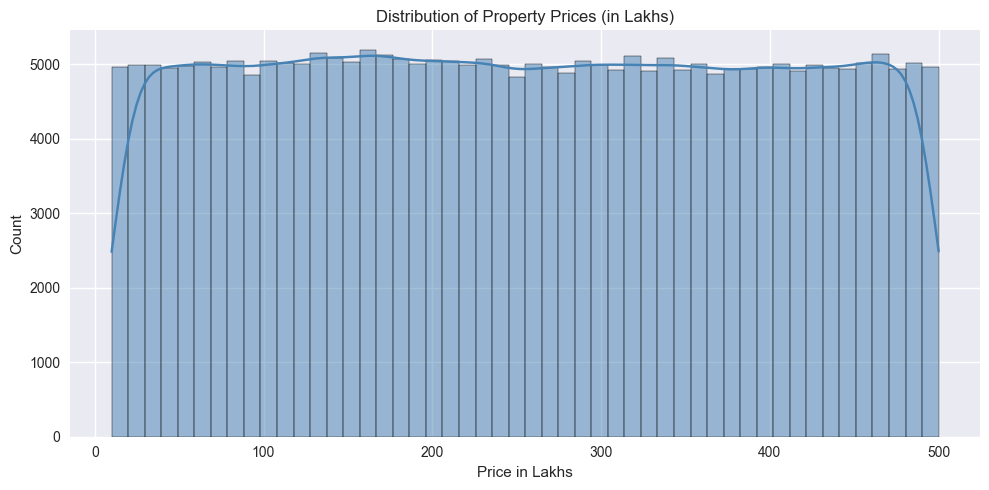

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df_original['Price_in_Lakhs'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Property Prices (in Lakhs)')
plt.xlabel('Price in Lakhs')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/q1_price_distribution.png')
plt.show()

 Q2: Distribution of Property Sizes

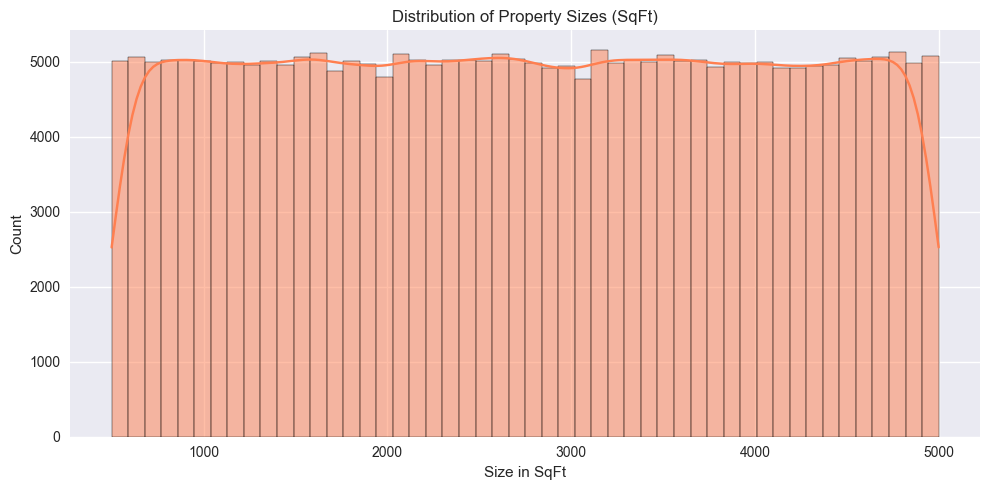

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df_original['Size_in_SqFt'], bins=50, kde=True, color='coral')
plt.title('Distribution of Property Sizes (SqFt)')
plt.xlabel('Size in SqFt')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/q2_size_distribution.png')
plt.show()

Q3: Price per SqFt by Property Type

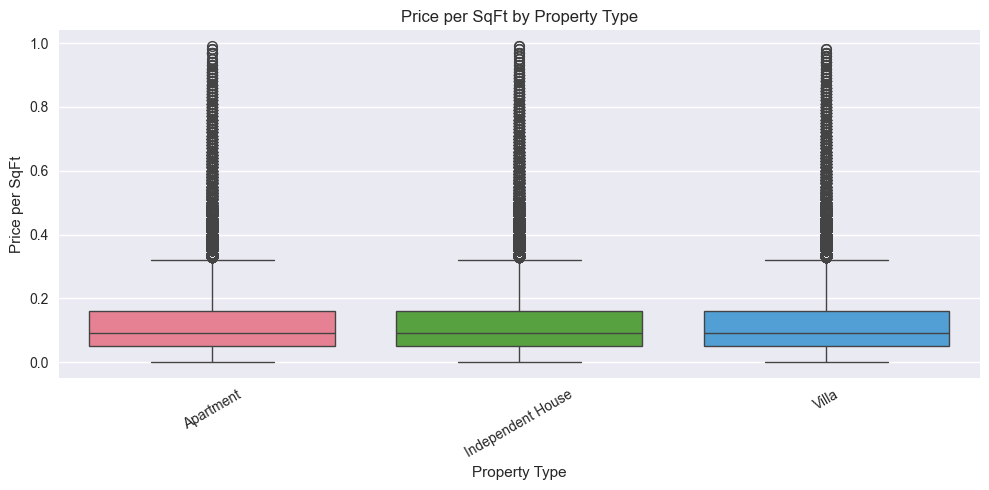

In [5]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_original, x='Property_Type', y='Price_per_SqFt', palette='husl')
plt.title('Price per SqFt by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Price per SqFt')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../data/q3_price_by_type.png')
plt.show()

Q4: Property Size vs Price

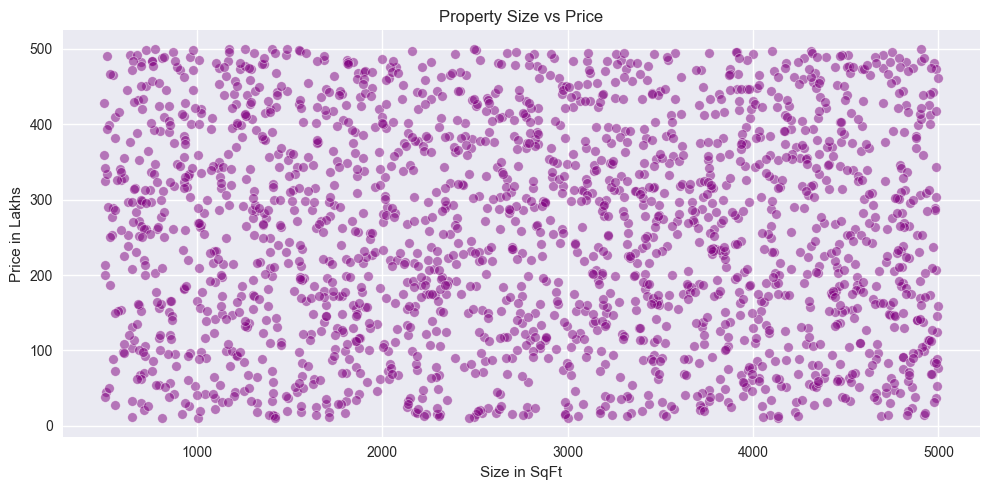

In [6]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_original.sample(2000), x='Size_in_SqFt', y='Price_in_Lakhs', alpha=0.5, color='purple')
plt.title('Property Size vs Price')
plt.xlabel('Size in SqFt')
plt.ylabel('Price in Lakhs')
plt.tight_layout()
plt.savefig('../data/q4_size_vs_price.png')
plt.show()

Q5: Outliers in Price per SqFt

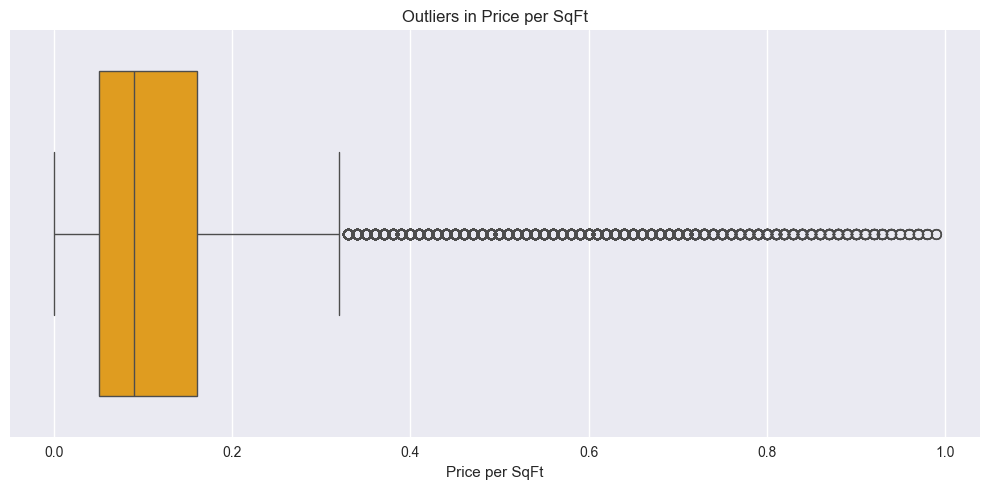

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_original, x='Price_per_SqFt', color='orange')
plt.title('Outliers in Price per SqFt')
plt.xlabel('Price per SqFt')
plt.tight_layout()
plt.savefig('../data/q5_outliers.png')
plt.show()

Q6 & Q7: Avg Price by State and City

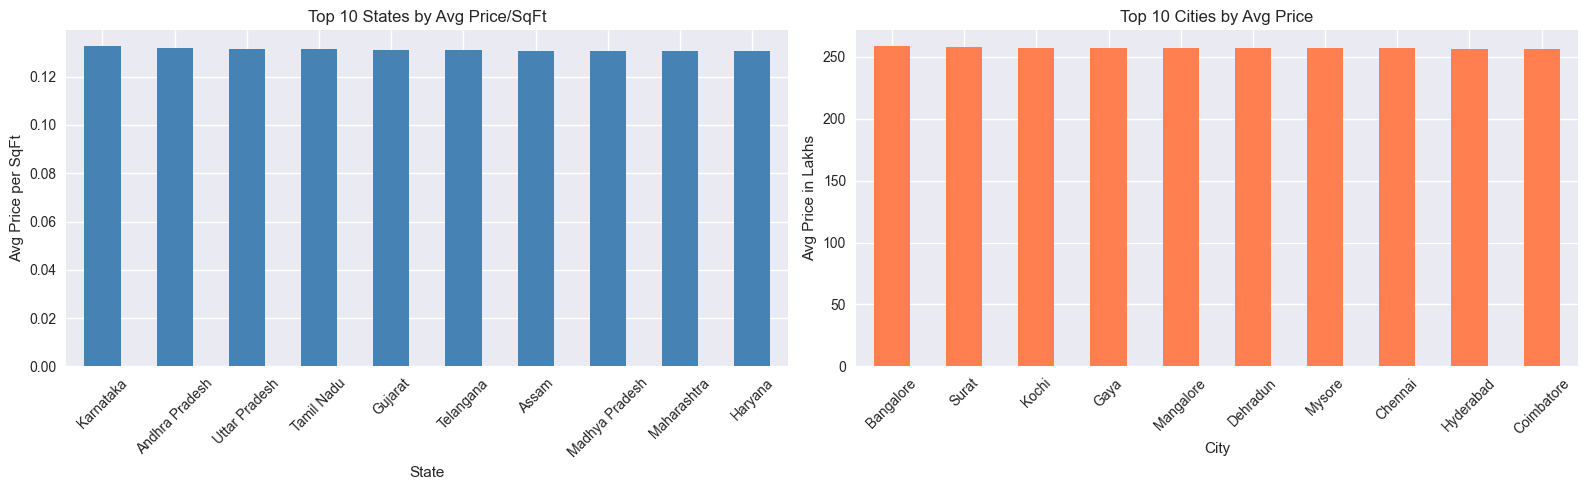

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# By State
state_avg = df_original.groupby('State')['Price_per_SqFt'].mean().sort_values(ascending=False).head(10)
state_avg.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 States by Avg Price/SqFt')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Avg Price per SqFt')
axes[0].tick_params(axis='x', rotation=45)

# By City
city_avg = df_original.groupby('City')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(10)
city_avg.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top 10 Cities by Avg Price')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Avg Price in Lakhs')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/q6_q7_price_by_location.png')
plt.show()

Q8 & Q9: Age by Locality & BHK by City

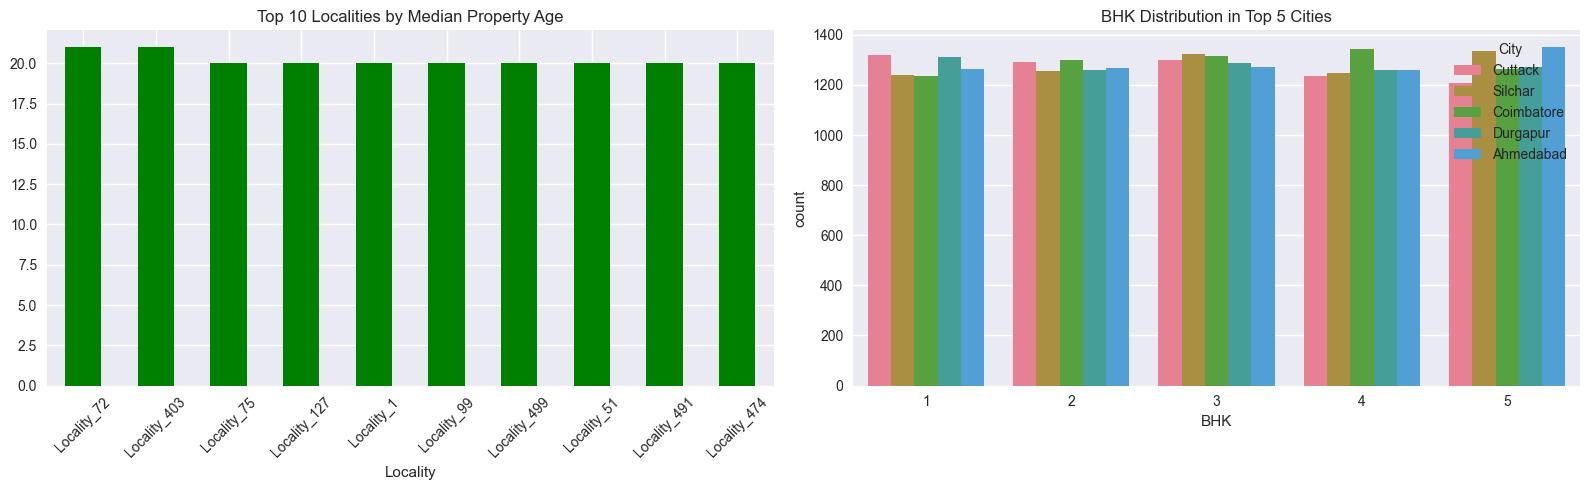

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Median age by locality (top 10)
locality_age = df_original.groupby('Locality')['Age_of_Property'].median().sort_values(ascending=False).head(10)
locality_age.plot(kind='bar', ax=axes[0], color='green')
axes[0].set_title('Top 10 Localities by Median Property Age')
axes[0].set_xlabel('Locality')
axes[0].tick_params(axis='x', rotation=45)

# BHK distribution across top 5 cities
top_cities = df_original['City'].value_counts().head(5).index
city_bhk = df_original[df_original['City'].isin(top_cities)]
sns.countplot(data=city_bhk, x='BHK', hue='City', ax=axes[1])
axes[1].set_title('BHK Distribution in Top 5 Cities')
axes[1].set_xlabel('BHK')

plt.tight_layout()
plt.savefig('../data/q8_q9_locality_bhk.png')
plt.show()

 Q11: Correlation Heatmap

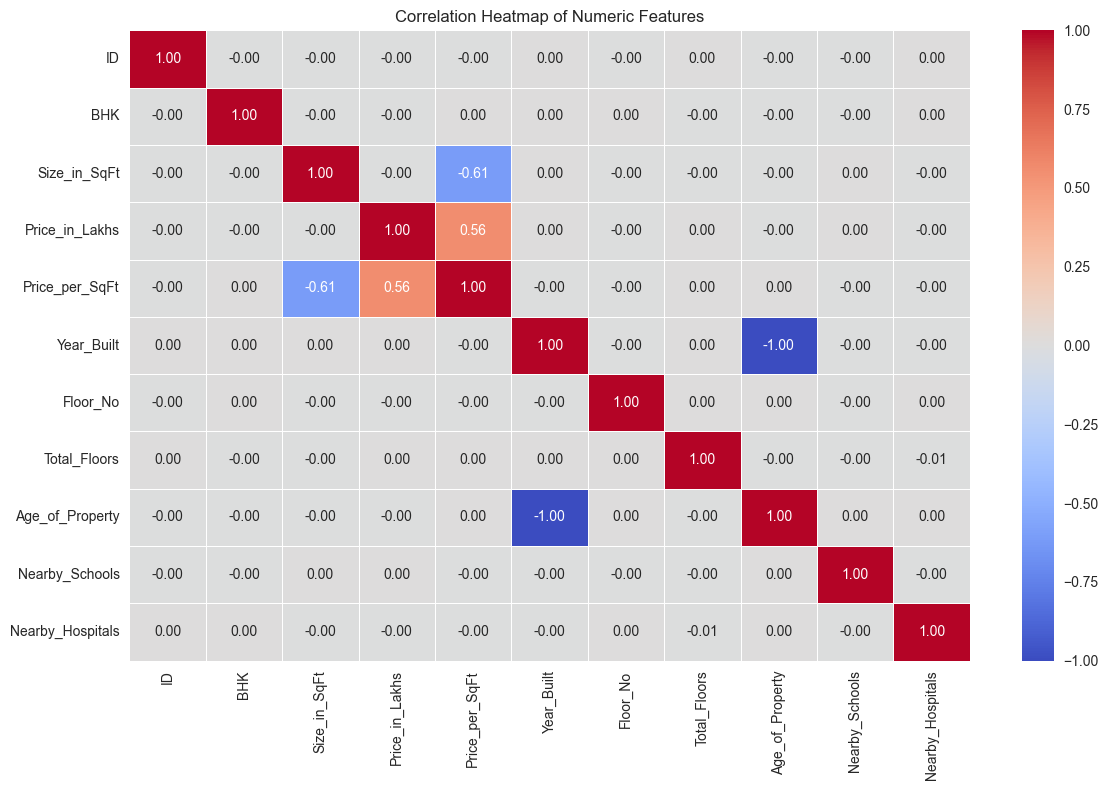

In [10]:
plt.figure(figsize=(12, 8))
numeric_df = df_original.select_dtypes(include=np.number)
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig('../data/q11_correlation_heatmap.png')
plt.show()

Q12 & Q13: Schools & Hospitals vs Price

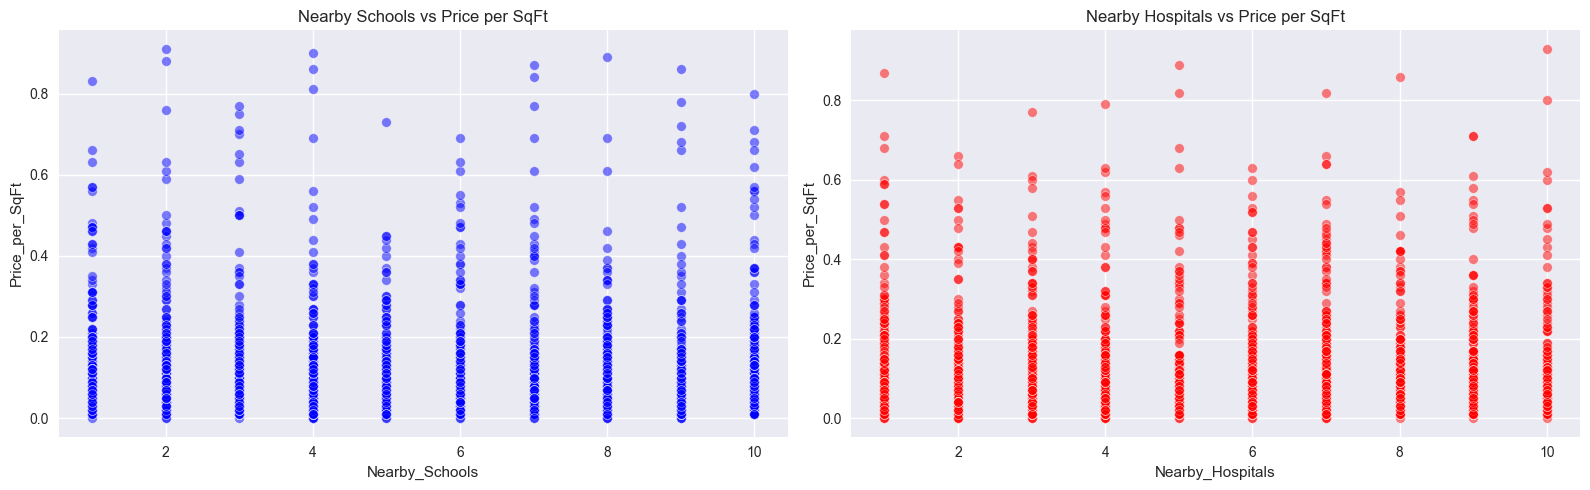

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.scatterplot(data=df_original.sample(2000), x='Nearby_Schools', y='Price_per_SqFt', alpha=0.5, ax=axes[0], color='blue')
axes[0].set_title('Nearby Schools vs Price per SqFt')

sns.scatterplot(data=df_original.sample(2000), x='Nearby_Hospitals', y='Price_per_SqFt', alpha=0.5, ax=axes[1], color='red')
axes[1].set_title('Nearby Hospitals vs Price per SqFt')

plt.tight_layout()
plt.savefig('../data/q12_q13_schools_hospitals.png')
plt.show()

Q14 : Furnished Status & Facing vs Price

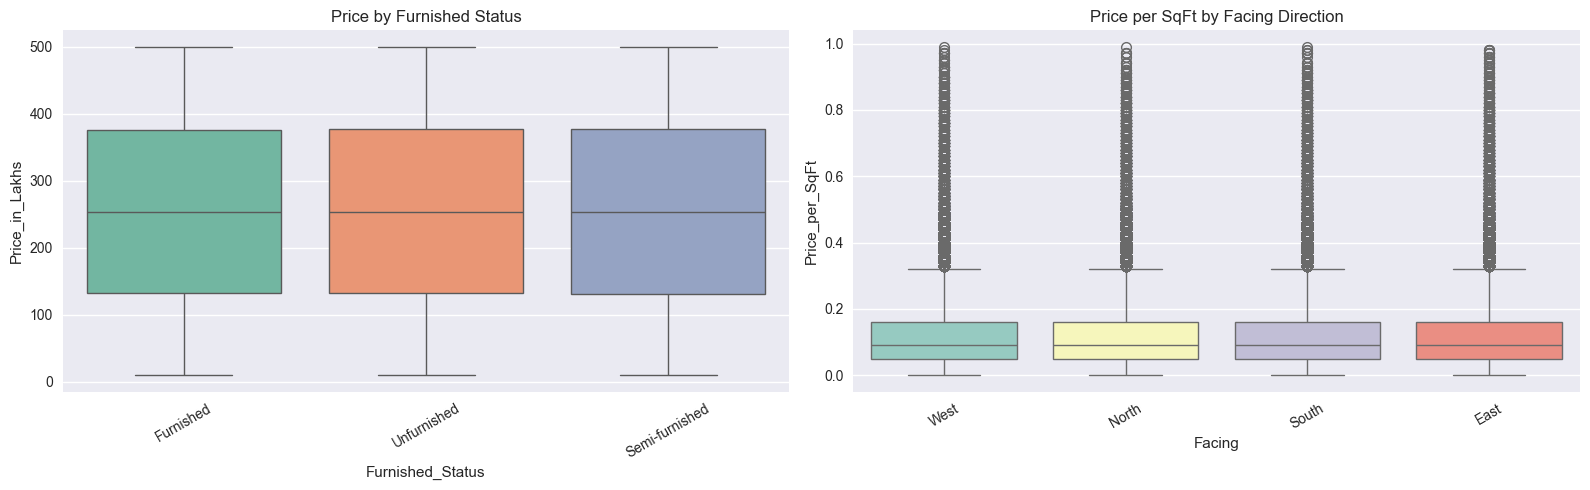

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df_original, x='Furnished_Status', y='Price_in_Lakhs', palette='Set2', ax=axes[0])
axes[0].set_title('Price by Furnished Status')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_original, x='Facing', y='Price_per_SqFt', palette='Set3', ax=axes[1])
axes[1].set_title('Price per SqFt by Facing Direction')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../data/q14_q15_furnished_facing.png')
plt.show()

Good Investment Distribution

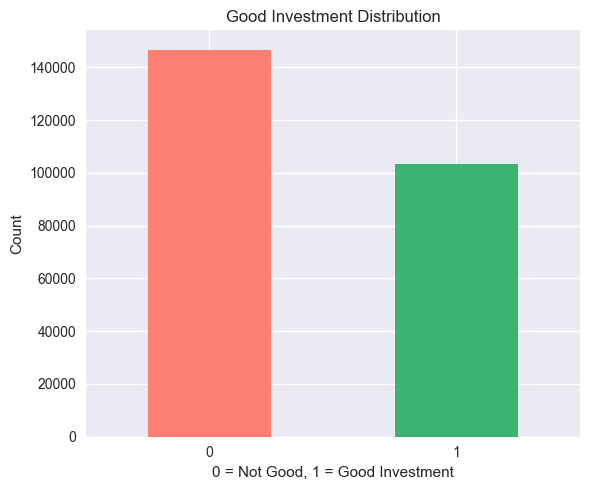

Good_Investment
0    146742
1    103258
Name: count, dtype: int64


In [15]:
plt.figure(figsize=(6, 5))
df['Good_Investment'].value_counts().plot(kind='bar', color=['salmon', 'mediumseagreen'])
plt.title('Good Investment Distribution')
plt.xlabel('0 = Not Good, 1 = Good Investment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/good_investment_dist.png')
plt.show()

print(df['Good_Investment'].value_counts())

 Q16 & Q17: Owner Type & Availability Status

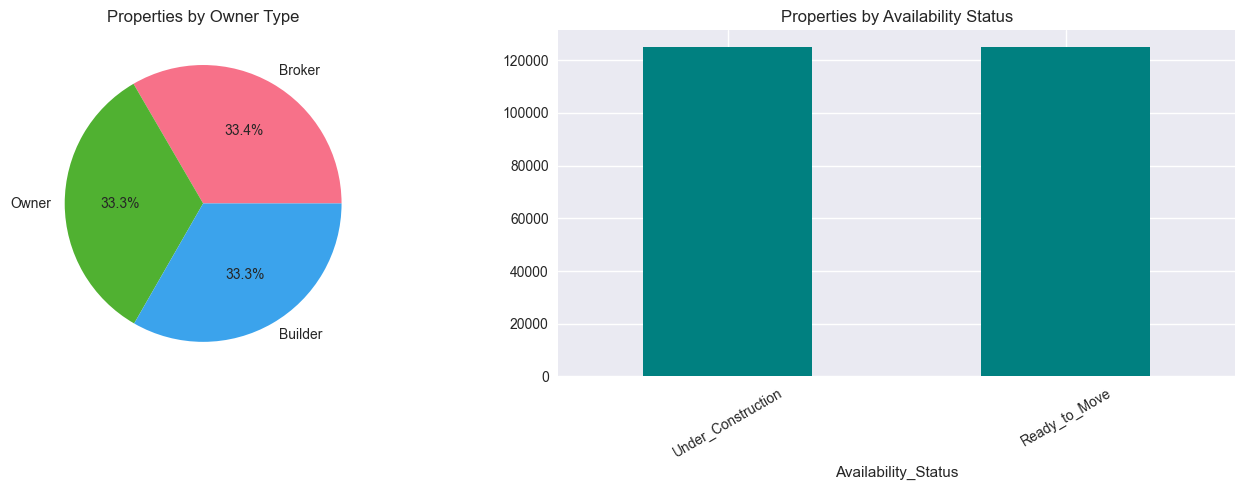

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_original['Owner_Type'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0], colors=sns.color_palette('husl', 3))
axes[0].set_title('Properties by Owner Type')
axes[0].set_ylabel('')

df_original['Availability_Status'].value_counts().plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Properties by Availability Status')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../data/q16_q17_owner_availability.png')
plt.show()

Q18, Q19, Q20: Parking, Amenities & Transport

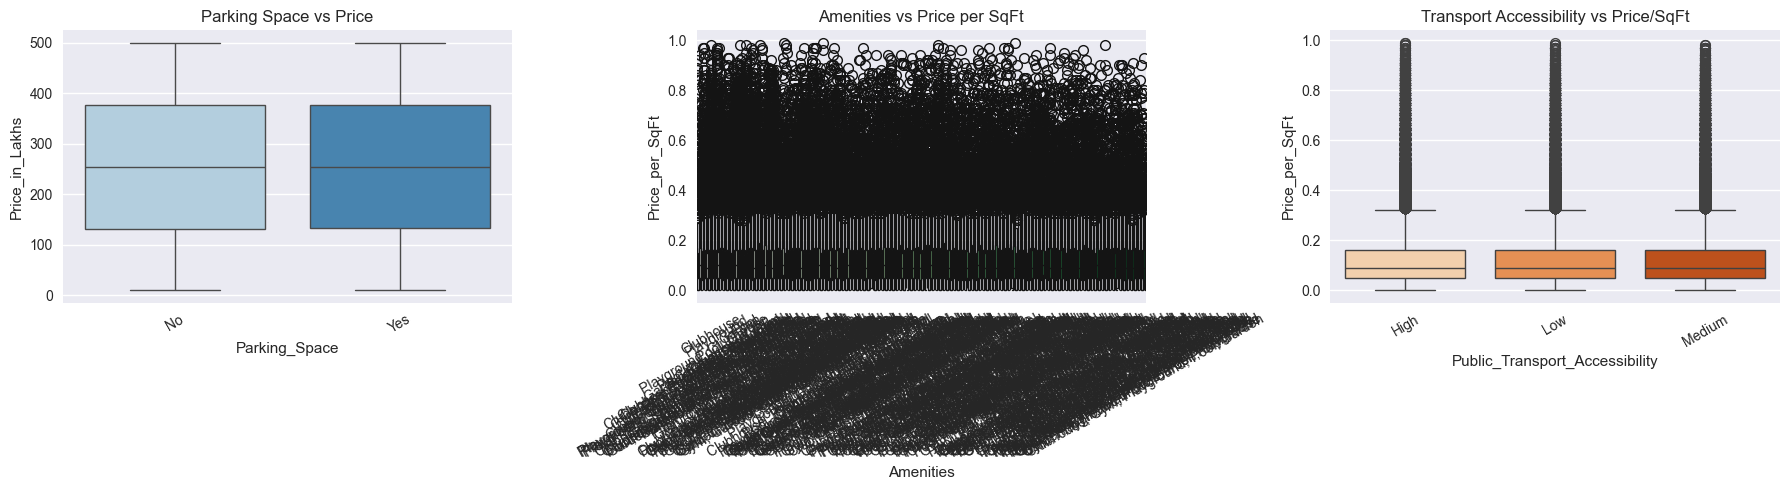

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Parking vs Price
sns.boxplot(data=df_original, x='Parking_Space', y='Price_in_Lakhs', ax=axes[0], palette='Blues')
axes[0].set_title('Parking Space vs Price')
axes[0].tick_params(axis='x', rotation=30)

# Amenities vs Price per SqFt
sns.boxplot(data=df_original, x='Amenities', y='Price_per_SqFt', ax=axes[1], palette='Greens')
axes[1].set_title('Amenities vs Price per SqFt')
axes[1].tick_params(axis='x', rotation=30)

# Transport vs Price per SqFt
sns.boxplot(data=df_original, x='Public_Transport_Accessibility', y='Price_per_SqFt', ax=axes[2], palette='Oranges')
axes[2].set_title('Transport Accessibility vs Price/SqFt')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../data/q18_q19_q20_amenities.png')
plt.show()